In [ ]:
%pip install pyarrow torch

In [ ]:
%pip install umap-learn scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import numpy as np
import pandas as pd
from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/tag-polysemy/clap-embeddings")
BASE = "clap_music_htsat"                # base name without extension
MAIN_F = OUT_DIR / f"{BASE}.parquet"     # the first existing file

parts = [MAIN_F] + sorted(OUT_DIR.glob(f"{BASE}.append_*.parquet"))
dataset = ds.dataset(parts, format="parquet")
tbl = dataset.to_table()
df = tbl.to_pandas() # columns: path (str), track_id (int), embedding (list[float32] len=512)
E = np.vstack(df["embedding"].to_numpy())
ids = df["track_id"].to_numpy()
paths = df["path"].to_numpy()
print(E.shape, len(paths))


(55701, 512) 55701


In [ ]:
print(ids[:5])
print(ids[-5:])
print(df.head(1))

[1100507 1129026  710586  492112 1318107]
[1286194  193580  377180  873934 1111131]
                                                path  track_id  \
0  /content/drive/MyDrive/tag-polysemy/mtg-audio-...   1100507   

                                           embedding  
0  [-0.027002594, -0.02030054, 0.0059665926, 0.06...  


In [ ]:
# L2-normalize rows (safe default for CLAP-like embeddings)
E = E.astype(np.float32, copy=False)
row_norms = np.linalg.norm(E, axis=1, keepdims=True) + 1e-8
E_unit = E / row_norms

OUT_DIR = Path("/content/drive/MyDrive/tag-polysemy/clap-embeddings/analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)


Cumulative explained variance at 30 components: 0.7740


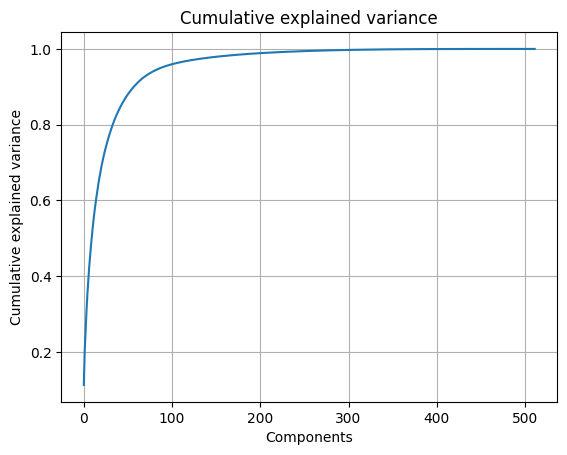

In [ ]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca = PCA()
pca.fit(E_unit)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

x_value_1_based = 30
# Convert to 0-based index for array access
x_index_0_based = x_value_1_based - 1

# Check if the index is valid
if x_index_0_based < len(cumulative_variance):
    cev_at_x = cumulative_variance[x_index_0_based]
    print(f"Cumulative explained variance at {x_value_1_based} components: {cev_at_x:.4f}") # format for readability
else:
    print(f"Cannot find CEV for {x_value_1_based} components. Max components available: {len(cumulative_variance)}")

plt.plot(cumulative_variance)
plt.title("Cumulative explained variance")
plt.xlabel("Components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

Cumulative explained variance at 50 components: 0.8771
Cumulative explained variance at 30 components: 0.7740

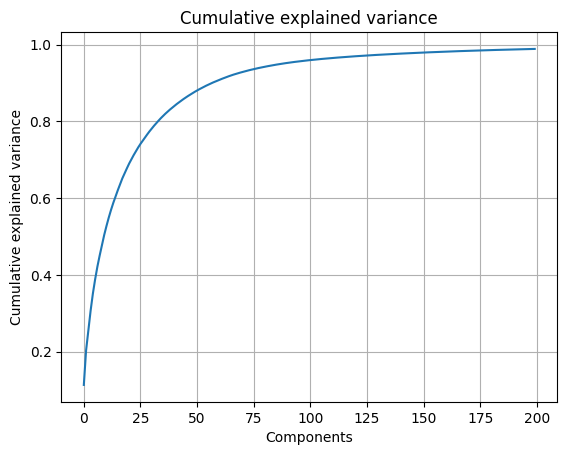

In [ ]:
pca = PCA(n_components=200)
pca.fit(E_unit)
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.title("Cumulative explained variance")
plt.xlabel("Components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

We get about 90-95% cumulative explained variance at 75 components. about 90 at 50 components, 80 at about 30 components.

In [ ]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca = PCA(n_components=50)
scores_pca = pca.fit_transform(E_unit)

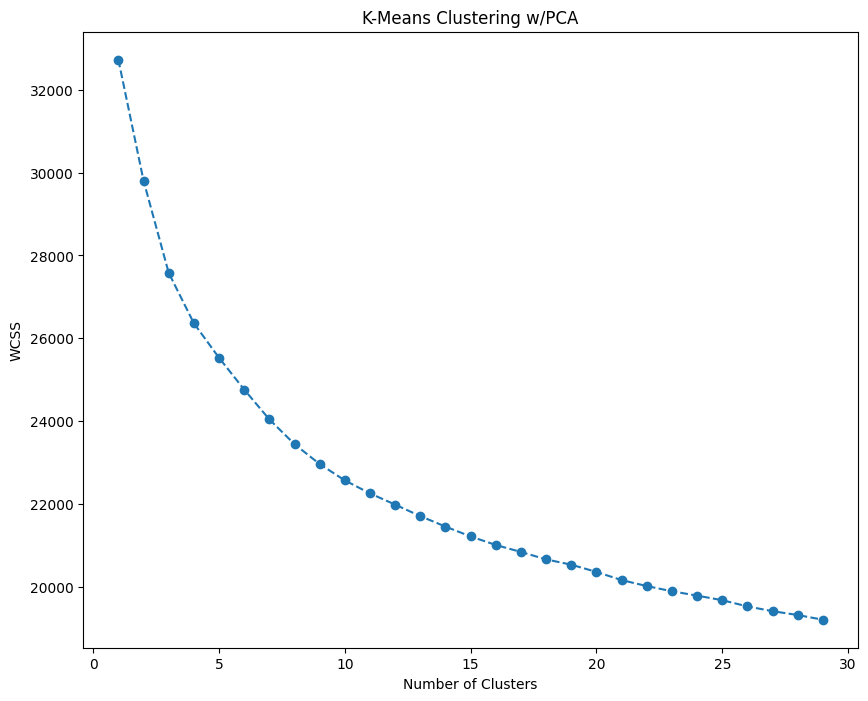

In [ ]:
wcss = []
for i in range(1, 30):
    kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=SEED)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

plt.figure(figsize=(10, 8))
plt.plot(range(1, 30), wcss, marker = 'o', linestyle = '--')
plt.title('K-Means Clustering w/PCA')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

We see an elbow at about 7 clusters. I would have guessed there would be more! How might we interpret the clusters?

At 50 components, i tried more clusters. 10 seems like a decent elbow here, but the curve is quite smooth since I am unsure how many there may actually be.

In [ ]:
SEED = 13
kmeans_pca = KMeans(n_clusters=10, init='k-means++', random_state=SEED)
kmeans_pca.fit(scores_pca)

KMeans(n_clusters=10, random_state=13)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipython-input-820833568.py:51: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


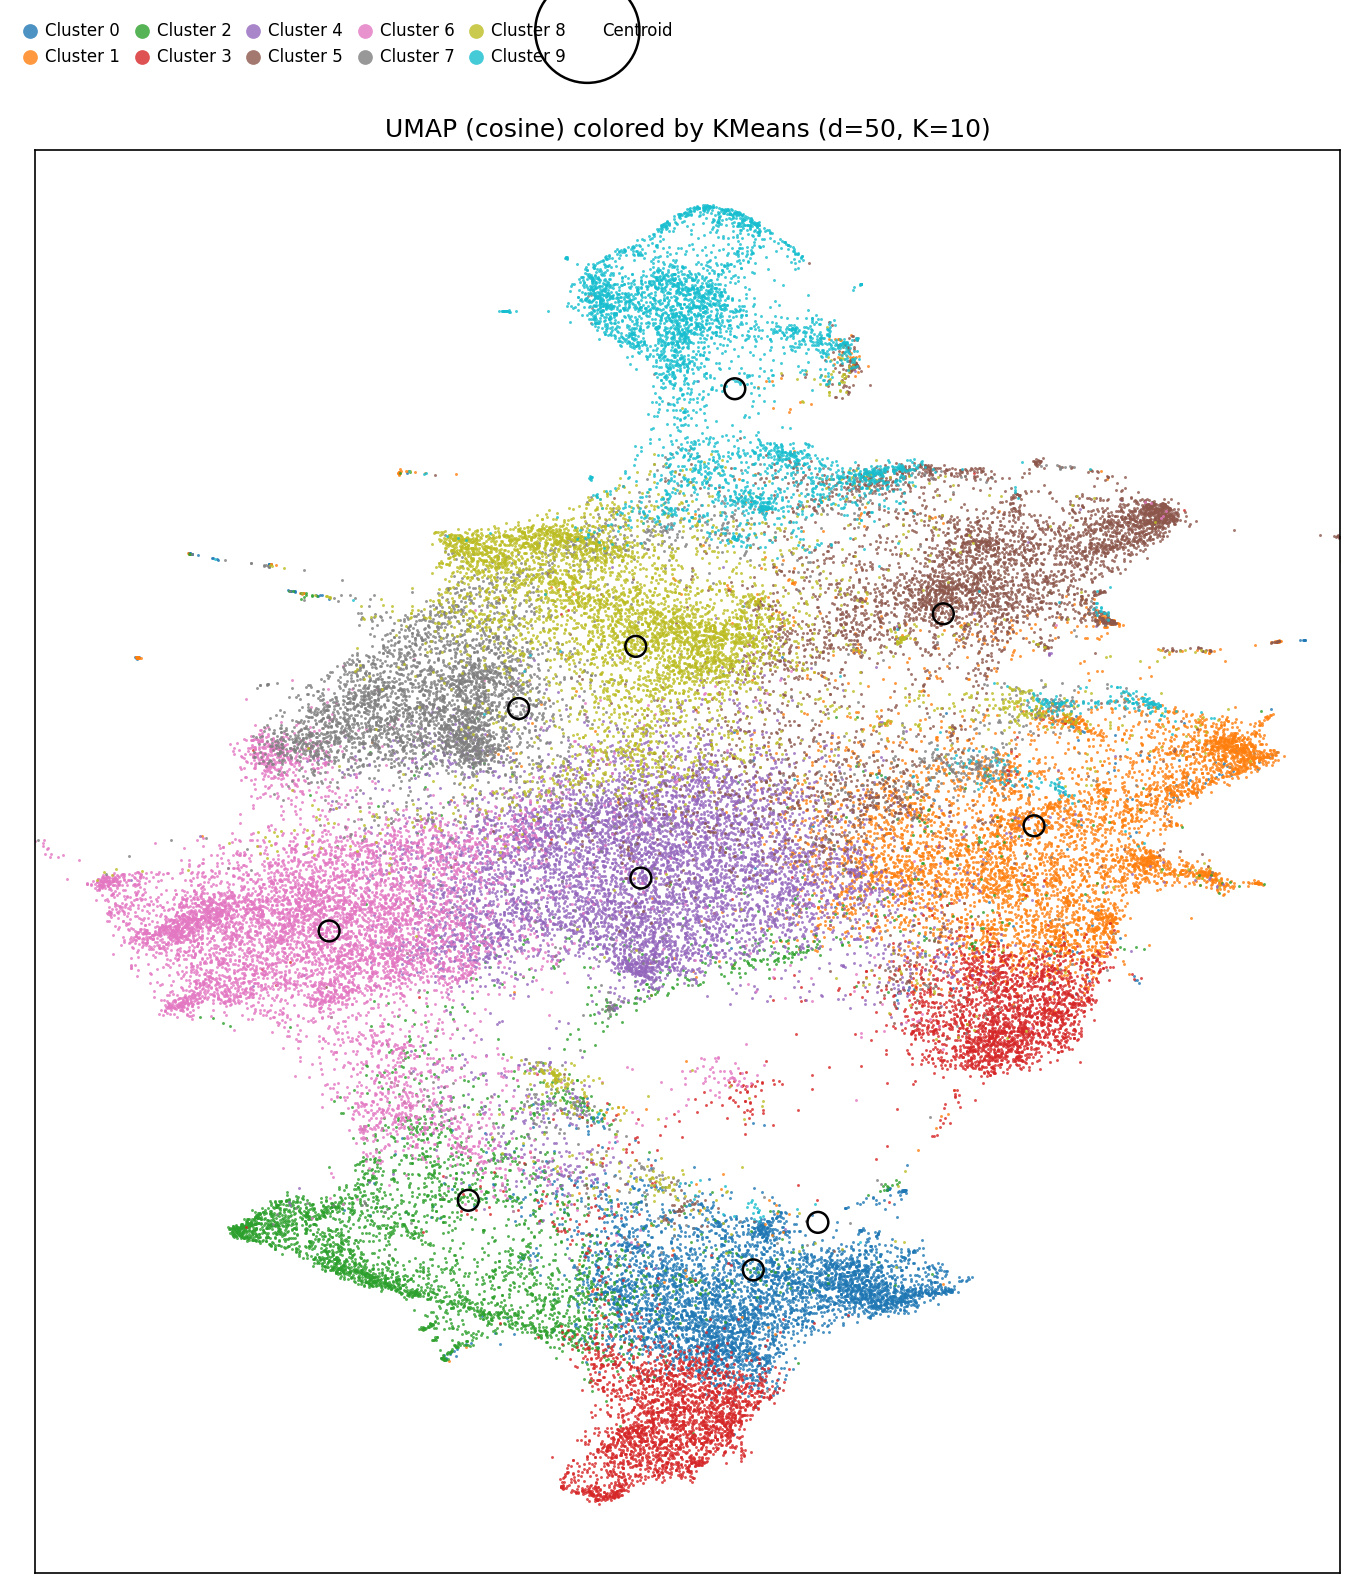

Saved artifacts in: /content/drive/MyDrive/tag-polysemy/embeddings/analysis


In [ ]:
import umap
import numpy as np
import matplotlib.pyplot as plt

# labels from k-means
labels = kmeans_pca.fit_predict(scores_pca)
K = int(labels.max() + 1)

# UMAP on unit-normalized embeddings
um = umap.UMAP(metric="cosine", random_state=SEED)
U = um.fit_transform(E_unit)  # shape: (N, 2)

# save artifacts
np.savez_compressed(OUT_DIR / "full_umap2_coords_labels_d50_K10.npz",
                    coords=U, labels=labels, ids=ids, paths=paths)

# limits to avoid outlier squeeze
xlo, xhi = np.percentile(U[:, 0], [1, 99])
ylo, yhi = np.percentile(U[:, 1], [1, 99])
pad_x = 0.1 * (xhi - xlo)
pad_y = 0.1 * (yhi - ylo)

# plot: one scatter per cluster
cmap = plt.get_cmap("tab10").colors
fig, ax = plt.subplots(figsize=(9, 10), dpi=150, constrained_layout=True)

for k in range(K):
    idx = (labels == k)
    ax.scatter(U[idx, 0], U[idx, 1],
               s=2, alpha=0.8, linewidths=0,
               color=cmap[k % 20], label=f"Cluster {k}",
               rasterized=True)

# plot centroids
centroids_2d = np.vstack([U[labels == k].mean(axis=0) for k in range(K)])
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           marker="o", s=100, facecolors="none",
           edgecolors="black", linewidths=1.2, label="Centroid", zorder=5)

# axes, legend, title
ax.set_xlim(xlo - pad_x, xhi + pad_x)
ax.set_ylim(ylo - pad_y, yhi + pad_y)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"UMAP (cosine) colored by KMeans (d=50, K={K})")
handles, labels_txt = ax.get_legend_handles_labels()
fig.legend(handles, labels_txt,
           loc="lower right", bbox_to_anchor=(0.5, 1.01),
           ncol=min(K + 1, 6), frameon=False,
           fontsize=8, markerscale=5, handlelength=1.0,
           columnspacing=0.8, handletextpad=0.4)
fig.tight_layout()
plt.show()

# save results
res_df = pd.DataFrame({
    "track_id": ids,
    "path": paths,
    "cluster": labels,
    "umap_x": U[:, 0],
    "umap_y": U[:, 1],
})
res_df.to_csv(OUT_DIR / "full_clusters_umap_d50_K10.csv", index=False)
print("Saved artifacts in:", OUT_DIR)


In [ ]:
sscore = silhouette_score(E_unit, labels, metric='cosine')
print(f"Silhouette Score: {sscore}")

Silhouette Score: 0.13227488100528717


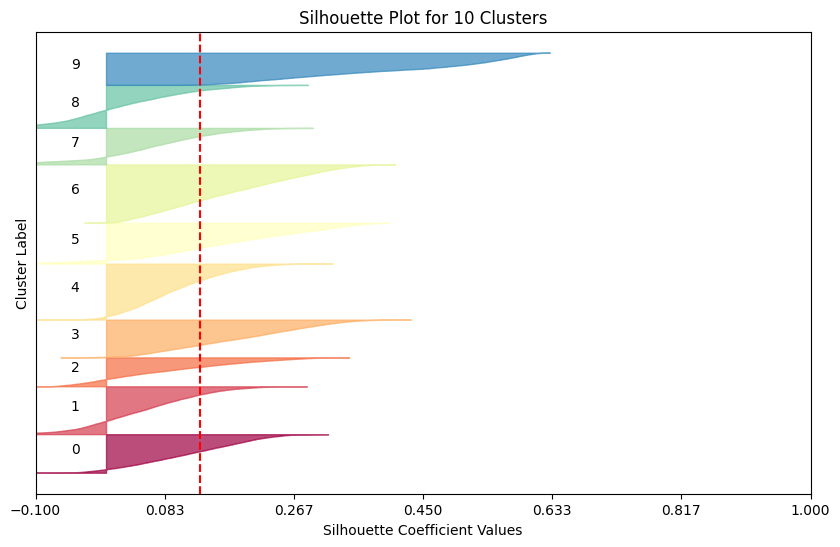

In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

silhouette_avg = silhouette_score(E_unit, labels, metric='cosine')
sample_silhouette_values = silhouette_samples(E_unit, labels, metric='cosine')
n_clusters = len(np.unique(labels))

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim([-0.1, .5])
y_lower = 10

for i in range(n_clusters):
    cluster_vals = sample_silhouette_values[labels == i]
    cluster_vals.sort()
    size_cluster_i = cluster_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.Spectral(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_title(f"Silhouette Plot for {n_clusters} Clusters")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
ax.set_yticks([])
ax.set_xticks(np.linspace(-0.1, 1, 7))
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

silhouette_avg = silhouette_score(E_unit, labels, metric='cosine')
sample_silhouette_values = silhouette_samples(E_unit, labels, metric='cosine')

# Attach to results dataframe
res_df = pd.DataFrame({
    "track_id": ids,
    "path": paths,
    "cluster": labels,
    "umap_x": U[:, 0],
    "umap_y": U[:, 1],
    "silhouette": sample_silhouette_values,
})

# sanity check
print("Overall silhouette average:", silhouette_avg)
print(res_df["silhouette"].describe())

Overall silhouette average: 0.1332454
count    55701.000000
mean         0.133245
std          0.137517
min         -0.238213
25%          0.041204
50%          0.113087
75%          0.204210
max          0.630042
Name: silhouette, dtype: float64
